# Consensus annotation with CellVote — PBMC3k

This tutorial runs `ov.single.CellVote` to combine **five** independent cell type
annotation methods into a single consensus label per cluster, addressing
[issue #694](https://github.com/omicverse/omicverse/issues/694) (updated
`CellVote` to pick the best celltype).

The input `adata` already has five annotation columns produced by the two
upstream tutorials:

| source notebook | obs columns added |
|---|---|
| `t_anno_noref.ipynb` (reference-free) | `celltypist_prediction`, `scsa_prediction`, `gpt4celltype_prediction` |
| `t_anno_ref.ipynb` (reference-based)  | `harmony_prediction`, `scVI_prediction` |

CellVote then takes a per-cluster majority within each of these five columns
and asks an LLM to arbitrate the final label using the cluster's top marker
genes as context.

## Setup: API key for the arbitration step

`CellVote` calls an LLM in the last step to pick between candidate labels.
Any OpenAI-compatible chat endpoint works. Sign up at one of the providers
below, export your key as `AGI_API_KEY` **before launching Jupyter**, and
configure ``provider`` / ``base_url`` / ``model`` on the ``vote()`` call.

| Provider | Sign up / get a key | Recommended `provider` / `model` |
|---|---|---|
| **DeepSeek** (cheap, used here) | https://platform.deepseek.com/api_keys | `provider="openai"`, `base_url="https://api.deepseek.com/v1"`, `model="deepseek-chat"` |
| OpenAI | https://platform.openai.com/api-keys | `provider="openai"`, `model="gpt-4o-mini"` |
| Qwen / Aliyun DashScope | https://help.aliyun.com/zh/dashscope/developer-reference/get-api-key | `provider="qwen"`, `model="qwen-plus"` |
| Kimi / Moonshot | https://platform.moonshot.cn/console/api-keys | `provider="kimi"`, `model="moonshot-v1-8k"` |

```bash
# in your shell, before launching jupyter:
export AGI_API_KEY=sk-your-actual-key
```


In [1]:
import os

# `AGI_API_KEY` is the env var omicverse reads for the LLM arbitration step.
# Export it in your shell before launching Jupyter (see the section above).
assert os.environ.get('AGI_API_KEY'), (
    'AGI_API_KEY is not set. See the previous cell for provider links.'
)

import anndata as ad
import scanpy as sc
import omicverse as ov

ov.plot_set(font_path='Arial')

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
Using already downloaded Arial font from: /tmp/omicverse_arial.ttf


Registered as: Arial
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.3rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 1) Load the pre-annotated pbmc3k

`data/pbmc3k_5anno.h5ad` was produced by running the noref + ref tutorials
end-to-end (celltypist + scsa + gpt4celltype + harmony + scVI) and merging
their outputs on shared cell barcodes.

In [2]:
adata = ad.read_h5ad('data/pbmc3k_5anno.h5ad')
print(adata)
print()
anno_cols = ['celltypist_prediction', 'scsa_prediction', 'gpt4celltype_prediction',
             'harmony_prediction', 'scVI_prediction']
for c in anno_cols:
    print(f'  {c}: {adata.obs[c].nunique()} unique values')

AnnData object with n_obs × n_vars = 2562 × 2000
    obs: 'nUMIs', 'mito_perc', 'ribo_perc', 'hb_perc', 'detected_genes', 'cell_complexity', 'n_counts', 'total_counts', 'n_genes', 'n_genes_by_counts', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'predicted_doublet', 'doublet_score', 'scdblfinder_doublet', 'scdblfinder_score', 'leiden', 'celltypist_prediction', 'scsa_prediction', 'gpt4celltype_prediction', 'harmony_prediction', 'scVI_prediction'
    var: 'gene_ids', 'mt', 'ribo', 'hb', 'n_cells', 'percent_cells', 'robust', 'highly_variable_features', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable'
    uns: 'REFERENCE_MANU', '_ov_provenance', 'history_log', 'hvg', 'leiden', 'log1p', 'neighbors', 'over_clustering', 'pca', 'rank_genes_groups', 'scaled|original|cum_sum_eigenvalues', 'scaled|original|pca_var_ratios', 'status', 'status_args', 'umap'
    obsm: 'X_pca', 'X_umap', 'celltypist_decision_

## 2) Compare the five annotations on UMAP

X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


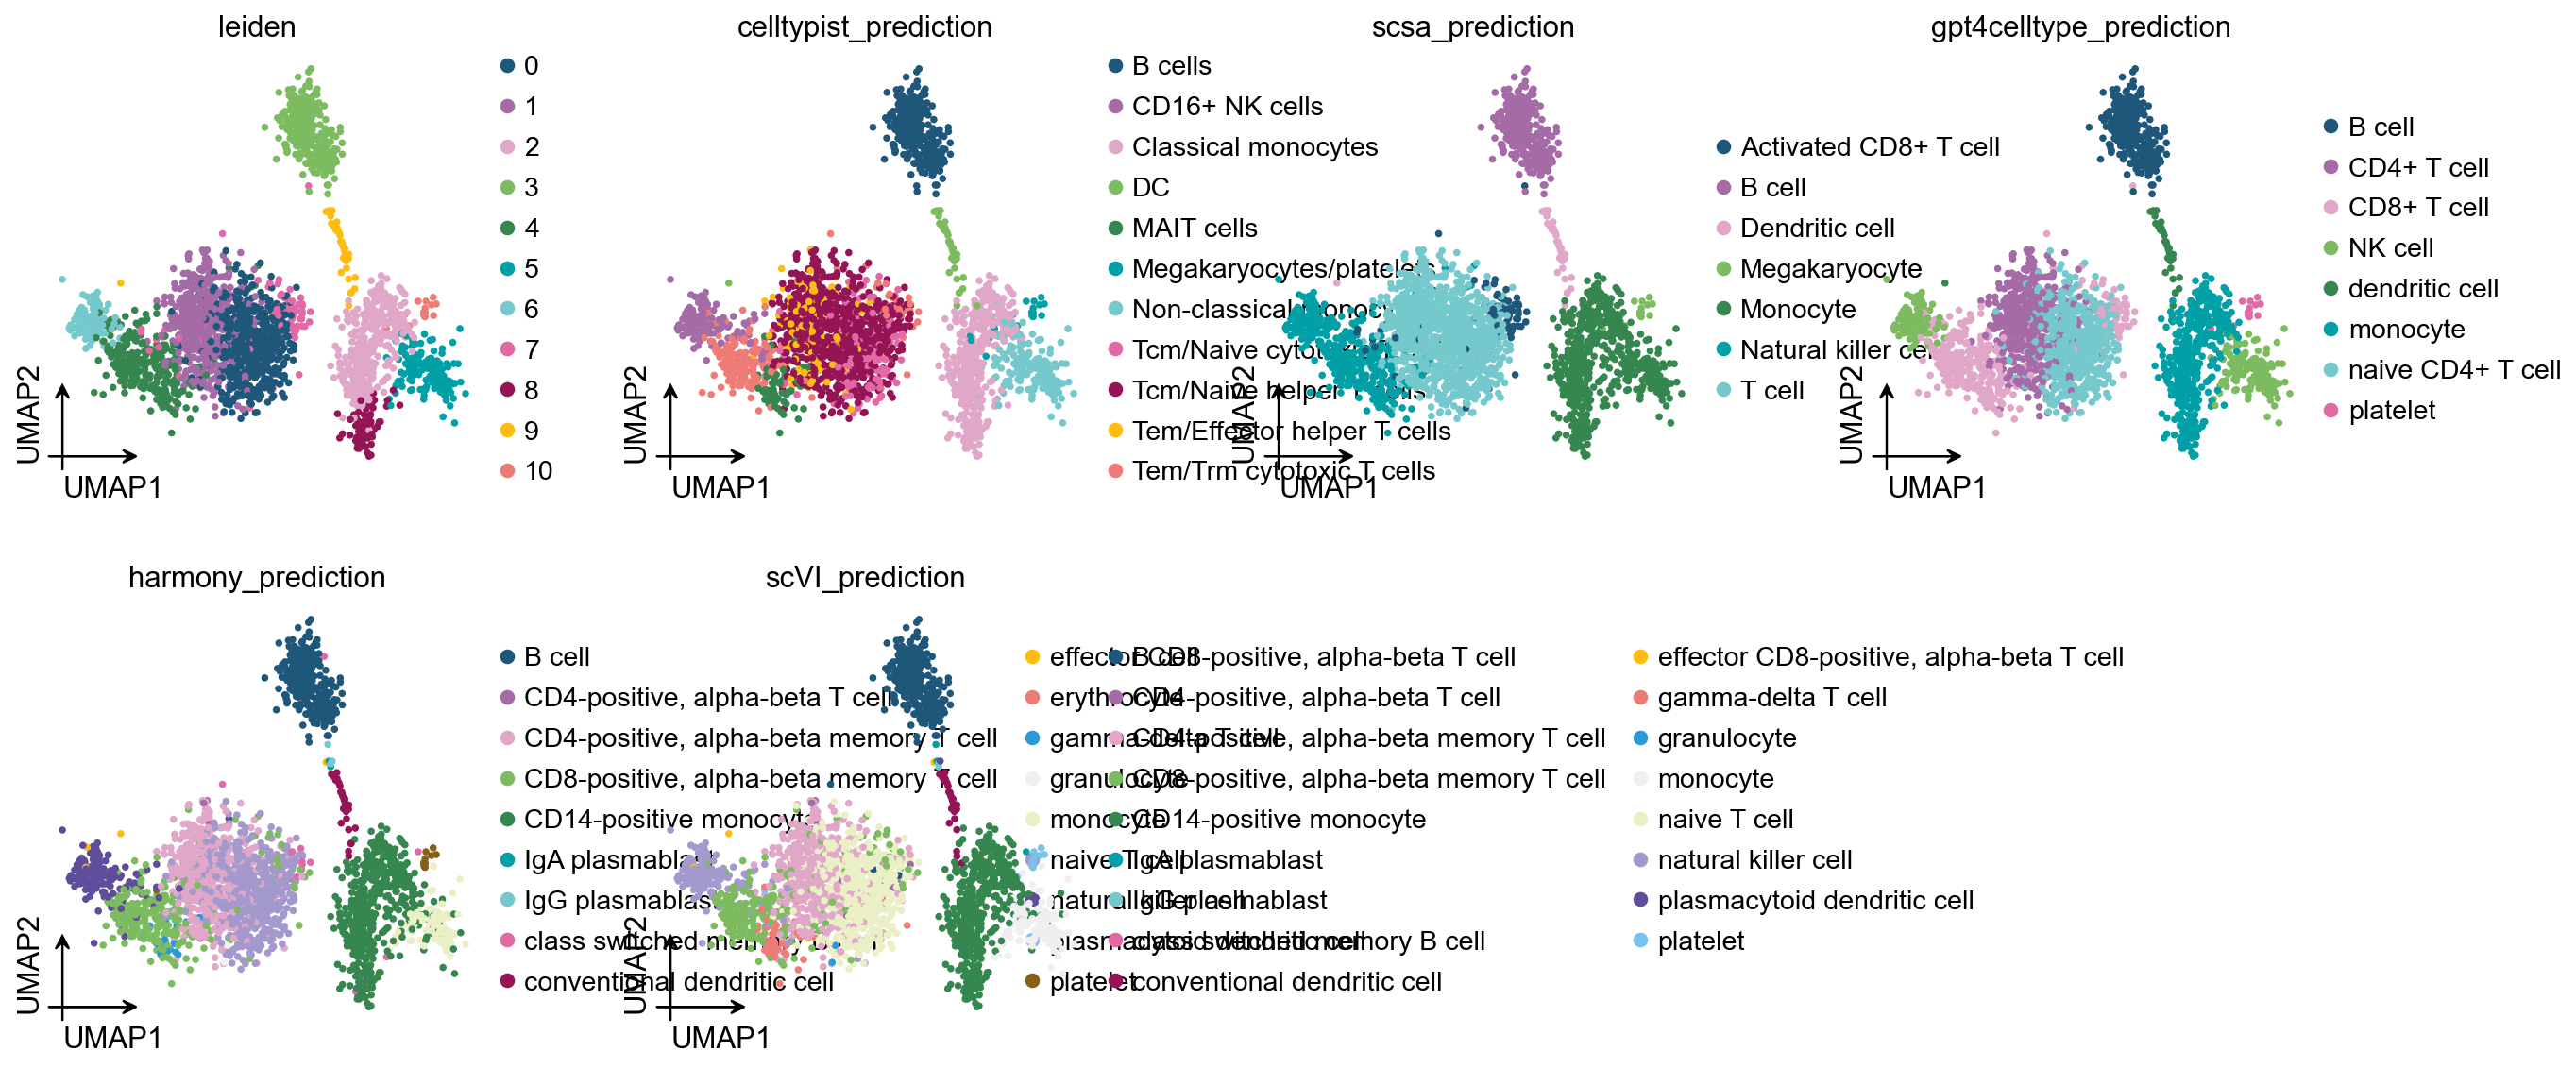

In [3]:
ov.pl.umap(
    adata,
    color=['leiden'] + anno_cols,
    frameon='small', palette=ov.pl.sc_color, ncols=4,
)

## 3) Compute marker genes per leiden cluster

`CellVote` uses the top markers as context when arbitrating between
candidate labels. `ov.single.get_celltype_marker` returns a
`dict[cluster_id -> list[str]]`.

In [4]:
marker_dict = ov.single.get_celltype_marker(
    adata, clustertype='leiden', topgenenumber=10,
    foldchange=1.5, pval_cutoff=0.05,
)
for cid, genes in list(marker_dict.items())[:3]:
    print(f'  leiden={cid}: {genes[:6]}')

...get cell type marker


  leiden=0: ['CCR7', 'EPHX2', 'PRKCQ-AS1', 'FHIT', 'LEF1', 'NELL2']
  leiden=1: ['CRIP2', 'CD2', 'AQP3', 'CD40LG', 'LTB', 'TRAT1']
  leiden=10: ['PF4', 'PPBP', 'SDPR', 'CALM3', 'RGS10', 'GPX1']


## 4) Run CellVote with all five annotation columns

`CellVote.vote()` does two things:

1. **Per cluster, per method** — picks the most-frequent label from that
   method's annotation column. This yields one candidate per method (so up
   to 5 candidates per cluster here).
2. **LLM arbitration** — sends `{candidates, top markers, species, tissue}`
   to the configured chat model and asks it to choose the most plausible
   identity. The result is written back to
   `adata.obs[result_key]` (default `CellVote_celltype`).

In [5]:
cv = ov.single.CellVote(adata)

result_dict = cv.vote(
    clusters_key='leiden',
    cluster_markers=marker_dict,
    celltype_keys=anno_cols,         # ← all 5 annotation sources
    provider='openai',                # use the OpenAI-compatible client
    base_url='https://api.deepseek.com/v1',
    model='deepseek-chat',
    species='human',
    organization='PBMC',
)
print()
print('CellVote consensus per cluster:')
for cid, label in sorted(result_dict.items(), key=lambda x: int(x[0]) if str(x[0]).isdigit() else x[0]):
    print(f'  leiden={cid}: {label}')

  0%|                                                                                                               | 0/11 [00:00<?, ?it/s]

  9%|█████████▎                                                                                             | 1/11 [00:00<00:09,  1.06it/s]

 18%|██████████████████▋                                                                                    | 2/11 [00:01<00:08,  1.12it/s]

 27%|████████████████████████████                                                                           | 3/11 [00:02<00:06,  1.17it/s]

 36%|█████████████████████████████████████▍                                                                 | 4/11 [00:03<00:05,  1.22it/s]

...

 82%|████████████████████████████████████████████████████████████████████████████████████▎                  | 9/11 [00:07<00:01,  1.24it/s]

 91%|████████████████████████████████████████████████████████████████████████████████████████████▋         | 10/11 [00:08<00:00,  1.25it/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:09<00:00,  1.16it/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:09<00:00,  1.18it/s]


CellVote consensus per cluster:
  leiden=0: tcm/naive helper t cell
  leiden=1: cd4-positive, alpha-beta memory t cell
  leiden=2: cd14-positive monocyte
  leiden=3: b cell
  leiden=4: cd8-positive, alpha-beta memory t cell
  leiden=5: non-classical monocyte
  leiden=6: cd16+ nk cell
  leiden=7: cd8-positive, alpha-beta memory t cell
  leiden=8: cd14-positive monocyte
  leiden=9: conventional dendritic cell
  leiden=10: megakaryocyte/platelet


## 5) Final consensus + per-cluster confidence

X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


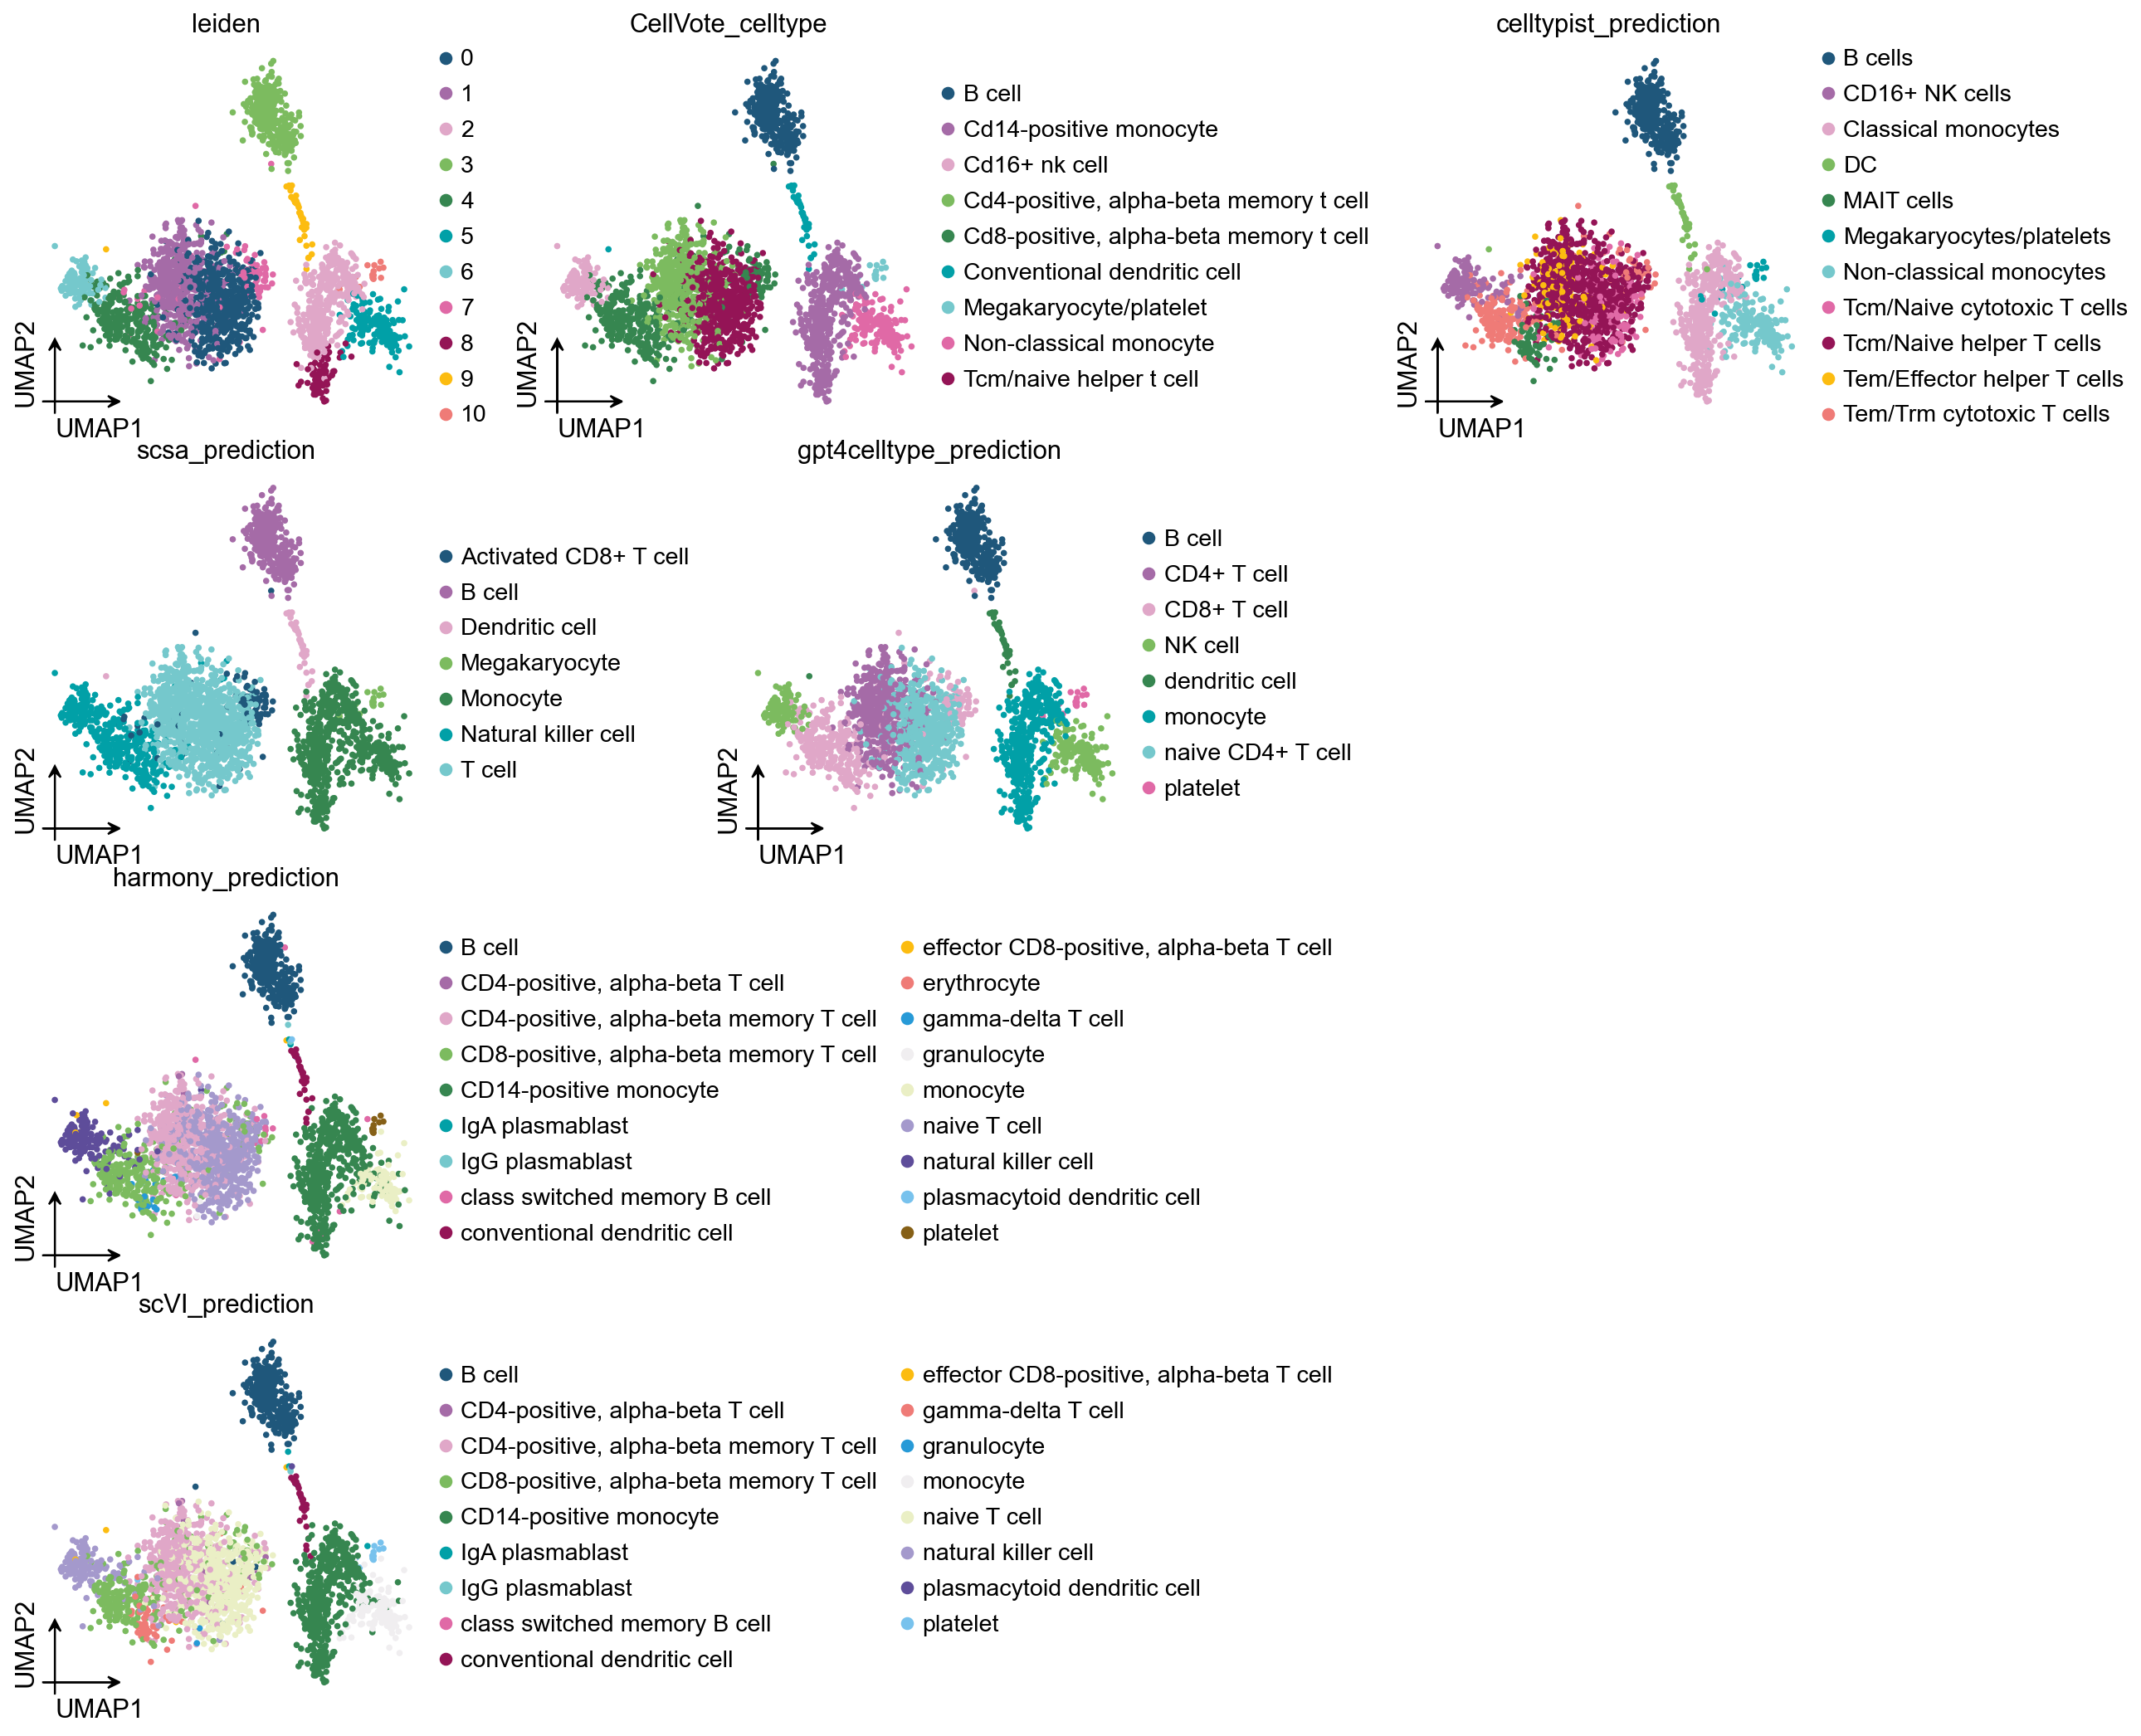

In [6]:
# layout='flow' guarantees no panel-to-panel legend overlap
ov.pl.umap(
    adata,
    color=['leiden', 'CellVote_celltype'] + anno_cols,
    frameon='small', palette=ov.pl.sc_color, ncols=4,
    layout='flow',
)

## 6) CellVote confidence (per-cluster consensus score)

`CellVote.vote()` now writes a per-cell confidence column
``adata.obs['CellVote_celltype_confidence']`` and a per-cluster score
table to ``adata.uns['CellVote_celltype_score_table']``.

The score is built from three metrics on the 5 input methods:

* **n_unique**         — distinct labels after normalisation (1..5)
* **plurality**        — fraction of methods agreeing with the most common label
* **vote_agreement**   — fraction of methods whose label is semantically
                        consistent with the final CellVote pick (token-set
                        Jaccard ≥ 0.34, with synonym + plural normalisation)
* **confidence**       — ``(plurality + vote_agreement) / 2`` ∈ [0, 1]

Clusters with `confidence < 0.6` are the ones most worth a manual look.

In [7]:
import pandas as pd

score_df = pd.DataFrame(adata.uns['CellVote_celltype_score_table'])
score_df = score_df.sort_values('confidence', ascending=False)
score_df

,cluster,n_cells,cellvote_label,n_unique,plurality,vote_agreement,confidence,methods_supporting
3,3,328,b cell,1,1.0,1.0,1.0,5/5
10,10,16,megakaryocyte/platelet,2,0.8,1.0,0.9,5/5
2,2,376,cd14-positive monocyte,2,0.6,1.0,0.8,5/5
8,8,80,cd14-positive monocyte,2,0.6,1.0,0.8,5/5
9,9,38,conventional dendritic cell,2,0.6,1.0,0.8,5/5
5,5,165,non-classical monocyte,3,0.6,0.8,0.7,4/5
0,0,545,tcm/naive helper t cell,4,0.4,0.8,0.6,4/5
1,1,513,"cd4-positive, alpha-beta memory t cell",4,0.4,0.6,0.5,3/5
4,4,283,"cd8-positive, alpha-beta memory t cell",4,0.4,0.6,0.5,3/5
6,6,128,cd16+ nk cell,3,0.6,0.4,0.5,2/5


X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


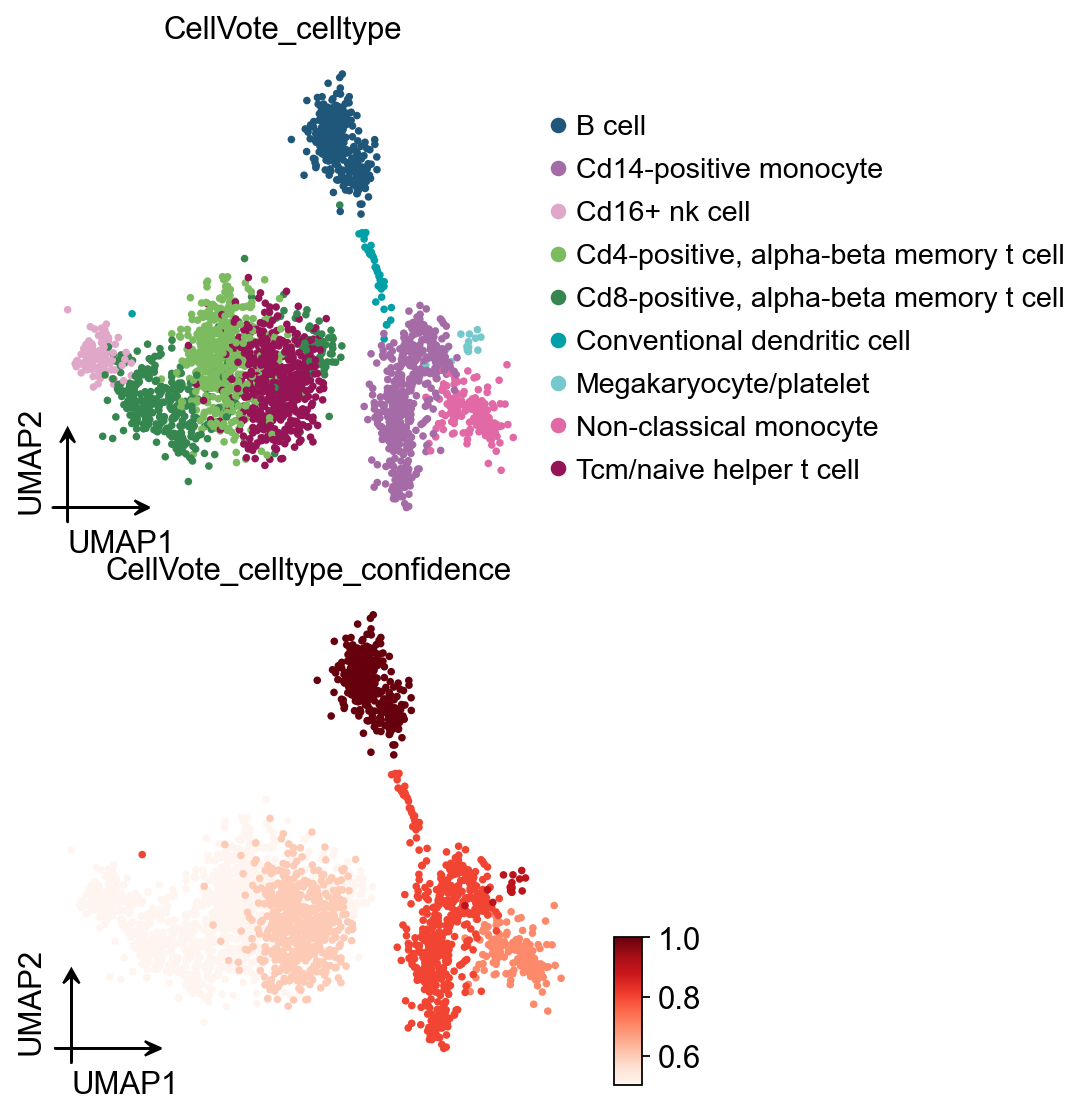

In [8]:
# Visualise where consensus is strong vs weak
ov.pl.umap(
    adata,
    color=['CellVote_celltype', 'CellVote_celltype_confidence'],
    frameon='small', palette=ov.pl.sc_color, ncols=4,
    cmap='Reds',
    layout='flow',
)

## 7) Per-cluster consensus table (5 methods + final + confidence)

In [9]:
cols_for_table = anno_cols + ['CellVote_celltype']
summary = (
    adata.obs.groupby('leiden', observed=True)[cols_for_table]
    .agg(lambda s: s.value_counts().index[0] if len(s) else '')
)
summary['n_cells'] = adata.obs.groupby('leiden', observed=True).size()
summary['confidence'] = pd.DataFrame(
    adata.uns['CellVote_celltype_score_table']
).set_index('cluster')['confidence']
summary = summary[['n_cells'] + cols_for_table + ['confidence']]
summary

,n_cells,celltypist_prediction,scsa_prediction,gpt4celltype_prediction,harmony_prediction,scVI_prediction,CellVote_celltype,confidence
leiden,,,,,,,,
0,545,Tcm/Naive helper T cells,T cell,naive CD4+ T cell,naive T cell,naive T cell,Tcm/naive helper t cell,0.6
1,513,Tcm/Naive helper T cells,T cell,CD4+ T cell,"CD4-positive, alpha-beta memory T cell","CD4-positive, alpha-beta memory T cell","Cd4-positive, alpha-beta memory t cell",0.5
2,376,Classical monocytes,Monocyte,monocyte,CD14-positive monocyte,CD14-positive monocyte,Cd14-positive monocyte,0.8
3,328,B cells,B cell,B cell,B cell,B cell,B cell,1.0
4,283,Tem/Trm cytotoxic T cells,Natural killer cell,CD8+ T cell,"CD8-positive, alpha-beta memory T cell","CD8-positive, alpha-beta memory T cell","Cd8-positive, alpha-beta memory t cell",0.5
5,165,Non-classical monocytes,Monocyte,NK cell,monocyte,monocyte,Non-classical monocyte,0.7
6,128,CD16+ NK cells,Natural killer cell,NK cell,natural killer cell,natural killer cell,Cd16+ nk cell,0.5
7,90,Tem/Trm cytotoxic T cells,Activated CD8+ T cell,CD8+ T cell,"CD8-positive, alpha-beta memory T cell","CD8-positive, alpha-beta memory T cell","Cd8-positive, alpha-beta memory t cell",0.5
8,80,Classical monocytes,Monocyte,monocyte,CD14-positive monocyte,CD14-positive monocyte,Cd14-positive monocyte,0.8


## 8) Notes

* Replace `provider`/`base_url`/`model` with any OpenAI-compatible chat
  endpoint (`openai`, `kimi`, `qwen`, `doubao`, or a self-hosted model).
* `result_key` overrides the output column name if you want to keep
  multiple CellVote runs side-by-side. The confidence column is named
  `f"{result_key}_confidence"` accordingly.
* `cluster_markers` is required — the LLM uses gene context to break
  ties between candidate labels.
* The confidence score is purely token-level (no extra LLM call); if you
  want stricter ontology-aware scoring, swap the threshold or run the
  `cellvote_consensus_score()` helper with a custom `jaccard_threshold`.